In [33]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [34]:
class BMI(TypedDict):
    height: float
    weight: float
    bmi: float
    verdict:str
    


In [35]:
def bmi_calculate(state:BMI)->BMI:
    weight = state['weight']
    height = state['height']
    bmi = weight/(height**2)
    state['bmi'] = round(bmi,2)
    return state


In [36]:
def category(state:BMI)->BMI:

    bmi = state['bmi']
    if bmi < 18.5:
        state['verdict']= "UnderWeight"
    elif (18.5 <= bmi < 24.9 ):
        state['verdict']= "Normal"
    elif(25 <= bmi < 29.9 ):
        state['verdict']= "OverWeight"
    else:
        state['verdict']= "Danger"

    return state

In [37]:
#define a graph
graph = StateGraph(BMI)

# add nodes
graph.add_node('calculate_bmi',bmi_calculate)
graph.add_node('verdict',category)
# add edges
graph.add_edge(START,'calculate_bmi')
graph.add_edge('calculate_bmi','verdict')
graph.add_edge('verdict',END)

# compile the graph
workflow = graph.compile()

In [38]:
# execute
# workflow.invoke({'height':1.65, 'weight':80})

In [39]:
initial_state = {'height':1.85,'weight':93}
final_state = workflow.invoke(initial_state)
print(final_state) 

{'height': 1.85, 'weight': 93, 'bmi': 27.17, 'verdict': 'OverWeight'}


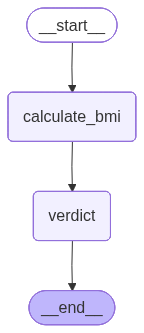

In [40]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())